# ✈️ Flight Price Prediction

# Notebook 02 : Exploratory Data Analysis (EDA)

## Objective

In this notebook we will:

- Explore the target variable
- Analyze numerical and categorical features
- Identify relationships with flight price
- Generate business insights
- Prepare for feature engineering

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

In [3]:
from pathlib import Path

DATA_DIR = Path("../data/raw")

df = pd.read_excel(DATA_DIR / "Train.xlsx")

In [4]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [5]:
df.shape

(10683, 11)

PART 1 TARGET VARIABLE

In [6]:
df["Price"].describe()

count    10683.000000
mean      9087.064121
std       4611.359167
min       1759.000000
25%       5277.000000
50%       8372.000000
75%      12373.000000
max      79512.000000
Name: Price, dtype: float64

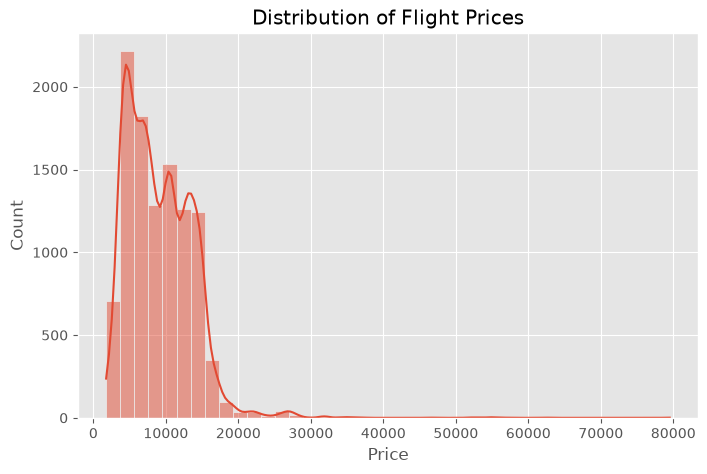

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df["Price"], bins=40, kde=True)

plt.title("Distribution of Flight Prices")

plt.show()

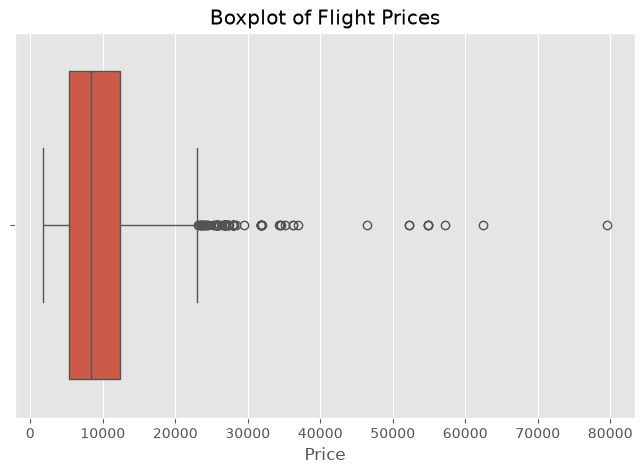

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Price"])

plt.title("Boxplot of Flight Prices")

plt.show()

PART 2 CATEGORICAL FEATURES

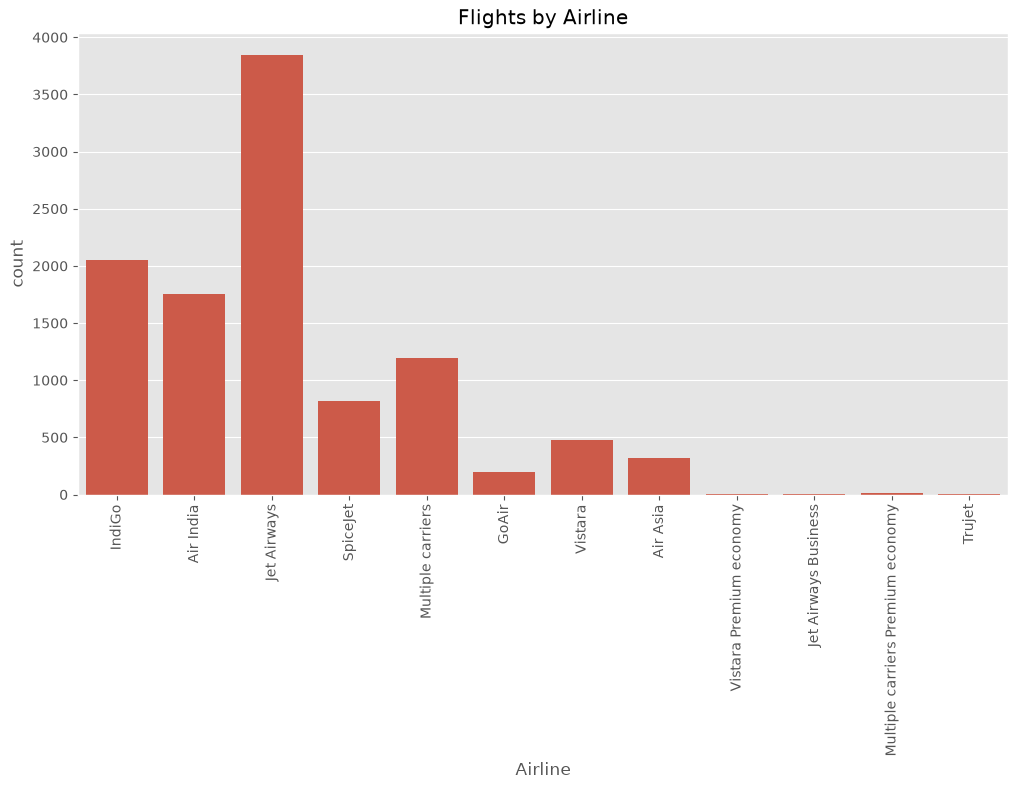

In [9]:
plt.figure(figsize=(12,6))

sns.countplot(data=df,x="Airline")

plt.xticks(rotation=90)

plt.title("Flights by Airline")

plt.show()

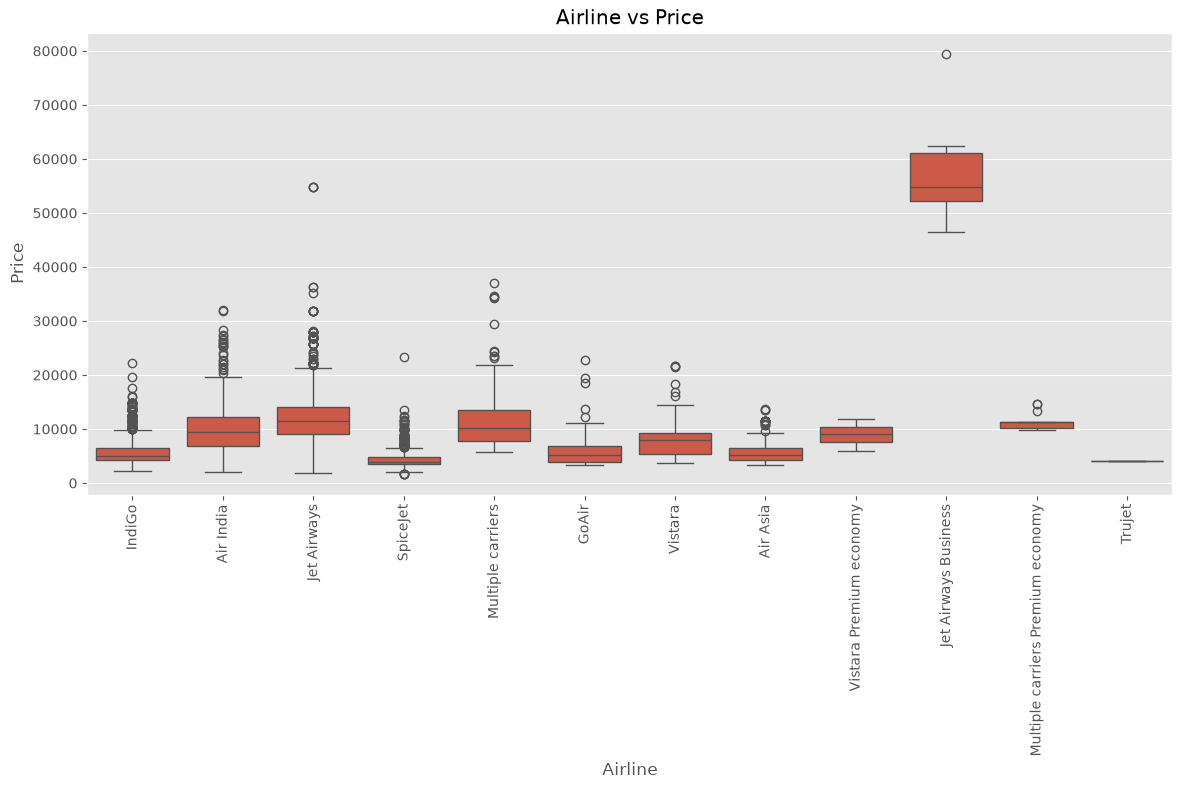

In [10]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="Airline",
    y="Price"
)

plt.xticks(rotation=90)

plt.title("Airline vs Price")

plt.show()

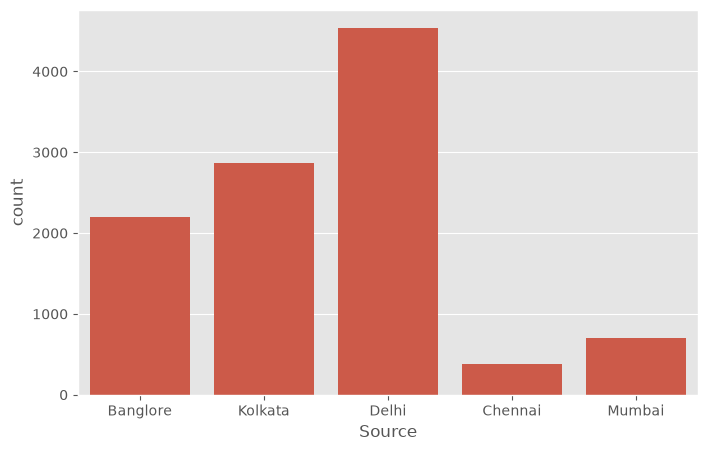

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Source")

plt.show()

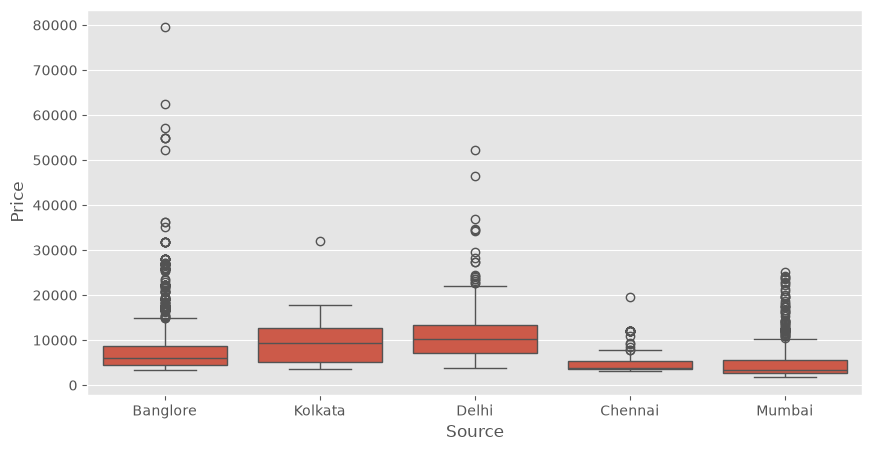

In [12]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Source",
    y="Price"
)

plt.show()

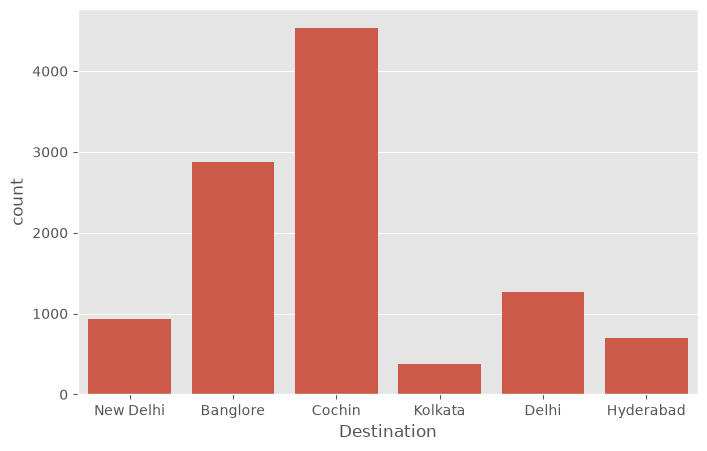

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Destination")

plt.show()

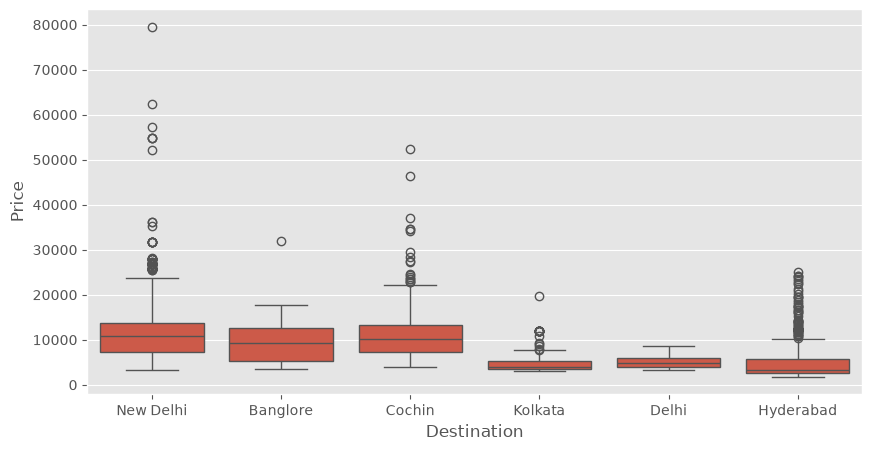

In [14]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Destination",
    y="Price"
)

plt.show()

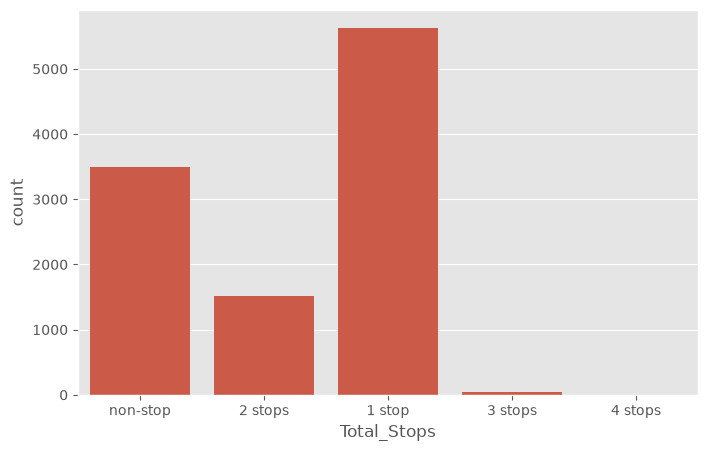

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Total_Stops")

plt.show()

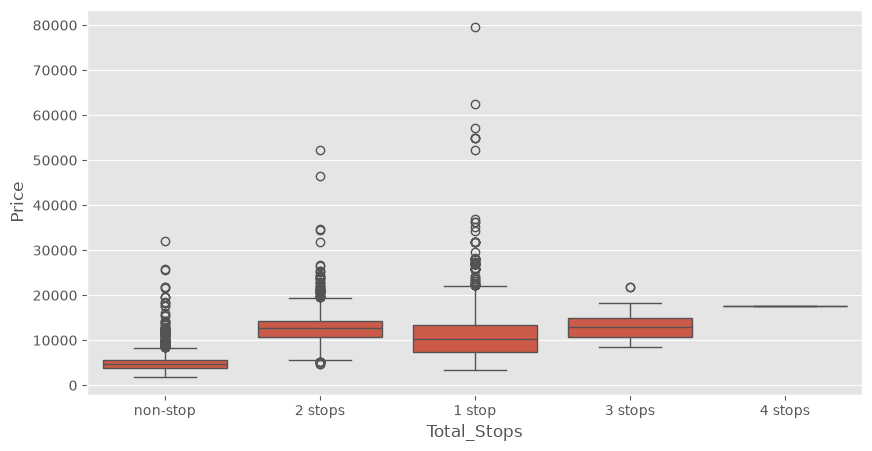

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Total_Stops",
    y="Price"
)

plt.show()

In [17]:
df["Additional_Info"].value_counts()

Additional_Info
No info                         8345
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

PART 3 TIME FEATURES

In [18]:
df["Dep_Time"].head()

0    22:20
1    05:50
2    09:25
3    18:05
4    16:50
Name: Dep_Time, dtype: str

In [19]:
df["Arrival_Time"].head()

0    01:10 22 Mar
1           13:15
2    04:25 10 Jun
3           23:30
4           21:35
Name: Arrival_Time, dtype: str

In [20]:
df["Duration"].head()

0    2h 50m
1    7h 25m
2       19h
3    5h 25m
4    4h 45m
Name: Duration, dtype: str

PART 4 CORRELATION

In [21]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,Price
Price,1.0


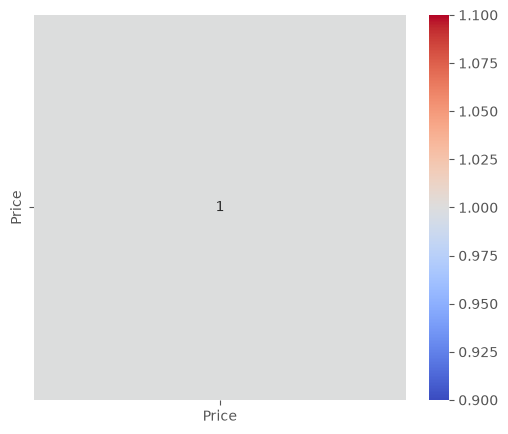

In [22]:
plt.figure(figsize=(6,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

PART 5 UNIQUE VALUES

In [23]:
for col in df.columns:

    print(col)

    print(df[col].nunique())

    print("-"*30)

Airline
12
------------------------------
Date_of_Journey
44
------------------------------
Source
5
------------------------------
Destination
6
------------------------------
Route
128
------------------------------
Dep_Time
222
------------------------------
Arrival_Time
1343
------------------------------
Duration
368
------------------------------
Total_Stops
5
------------------------------
Additional_Info
10
------------------------------
Price
1870
------------------------------


PART 6 INSIGHTS

# Key Insights

## Price

- Flight prices are positively skewed.
- Presence of high-priced outliers.

## Airline

- Airline has a strong influence on ticket price.

## Source

- Different source cities show different price distributions.

## Destination

- Destination also impacts ticket prices.

## Stops

- Flights with more stops generally tend to have higher prices.

## Duration

- Stored as text.
- Needs conversion into numerical values.

## Date & Time

- Stored as strings.
- Useful features like day, month, departure hour, and arrival hour can be extracted later.

## Additional_Info

- Mostly contains "No Info".
- May not provide significant predictive value.